<a href="https://colab.research.google.com/github/SampMark/Deep-Learning/blob/main/Transformer_Model_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Implementação de Transformers em Keras**

Aqui vamos explorar e desmistificar a arquitetura Transformer, considerada um "divisor de águas" no campo do aprendizado profundo, especialmente no Processamento de Linguagem Natural (PLN). Os Transformers se tornaram a espinha dorsal de modelos de ponta (tais como o BERT e GPT). Sua aplicação se expandiu para além do PLN, alcançando **visão computacional** e **análise de séries temporais**, conforme mencionado no artigo seminal "_Attention is All You Need_" de Vaswani Ashish _et al_.

Neste notebook serão aplicados conceitos fundamentais por trás da arquitetura Transformer para uma compreensão clara porque os Transformers são tão importantes, quais são seus componentes principais (com ênfase na "autoatenção") e como eles se interligam. Trata-se de passo inicial indispensável para quem busca dominar a construção de modelos Transformer.

### **Vantagens dos Transformers sobre Modelos Sequenciais de Redes Neurais**

**Por que Transformers são ideais para lidar com dados sequências?**

Dados sequenciais são definidos pela ordem e pelas interdependências entre seus elementos (o significado de uma palavra depende do contexto, o valor futuro de uma série temporal depende do passado, e por aí em diante). Modelos tradicionais como Redes Neurais Recorrentes (RNN) e _Long Short-Term Memory_ (LSTM) processam a sequência elemento por elemento, o que intrinsecamente limita sua capacidade nos seguintes aspectos:

* **Captura de Dependências de Longo Alcance**: a informação de elementos distantes pode se diluir ou se perder ao longo do processamento sequencial (problema do desaparecimento/explosão de gradientes).
* **Paralelização**: a natureza inerentemente sequencial do processamento impede a paralelização eficiente durante o processo de treinamento, tornando-o lento e até inviável para sequências longas.
Os Transformers abordam tais limitações de forma inteligente através do mecanismo de autoatenção (_self-attention_). Ao calcular a atenção, o modelo considera todas as posições da sequência simultaneamente para determinar a representação de cada posição, com efeito, isto permite:

1. Captura direta de dependências, isto é, as relações entre elementos distantes podem ser aprendidas diretamente, sem a necessidade de propagar informação passo a passo.
2. Processamento em Paralelo, como as representações de todas as posições podem ser calculadas independentemente (dentro da camada de atenção), o processo é altamente paralelizável, resultando em treinamentos muito mais rápidos, especialmente em hardware moderno (GPUs/TPUs).

### **Arquitetura dos transformers**

Possuem uma arquitetura "Codificador-Decodificador" (_Encoder-Decoder_), em que o foco principal recai sobre a "autoatenção", através dos vetores `Query`,` Key` e `Value`, os quais permitem que o modelo pondere sobre a relevância de diferentes partes da entrada ao processar uma informação específica.

Outros componentes auxiliares, mas vitais, são a  codificação posicional, as redes neurais  _feed-forward_, conexões residuais e a normalização de camada, os quais também têm seus papeis na preservação da ordem sequencial, voltados a transformação de dados e estabilização do treinamento.

* **Diferenciação Encoder vs. Decoder**: as funções do codificador (entender a entrada) e do decodificador (gerar a saída), a atenção cruzada (cross-attention) como um mecanismo adicional no decodificador, lhes permite "consultar" a saída do codificador durante o processo de geração.

Tais componentes são implementados por meio do Keras em classes específicas (`SelfAttention`, `TransformerEncoder`, `TransformerDecoder`) e métodos essenciais (`__init__, call`).



In [ ]:
!pip install tensorflow scikit-learn pyarrow

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import requests
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization
from sklearn.preprocessing import MinMaxScaler

In [3]:
# @title Cria um dataset sintético de preços de ações
np.random.seed(42)
data_length = 2000  # Adjust data length as needed
trend = np.linspace(100, 200, data_length)
noise = np.random.normal(0, 2, data_length)
synthetic_data = trend + noise

# Crie o DataFrame e salva como 'stock_prices.csv'
data = pd.DataFrame(synthetic_data, columns=['Close'])
data.to_csv('stock_prices.csv', index=False)
print("Dataset sintético stock_prices.csv criado e carregado.")

Dataset sintético stock_prices.csv criado e carregado.


# **Carregamento e Preparação dos Dados**

---

**Objetivo**: Carregar o dataset, selecionar os preços de fechamento (Close) e normalizá-los.

In [4]:
# @title Função para carregar e pré-processar o dataset
def load_and_preprocess_data(file_path, feature='Close'):
    data = pd.read_csv(file_path)
    close_prices = data[[feature]].values

    # Aplicação do MinMaxScaler para normalização
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(close_prices)

    return scaled_data, scaler

# Função para preparar o dataset para treinamento de modelos RNN/LSTM
def create_dataset(data, time_step=1):
    X, Y = [], []

    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])

    X, Y = np.array(X), np.array(Y)
    X = np.reshape(X, (X.shape[0], X.shape[1], 1))

    return X, Y

# Parâmetros
FILE_PATH = 'stock_prices.csv'
TIME_STEP = 100

# Execução principal
data, scaler = load_and_preprocess_data(FILE_PATH)
X, Y = create_dataset(data, TIME_STEP)

# Exibindo os shapes dos dados preparados
print(f'Shape de X: {X.shape}')
print(f'Shape de Y: {Y.shape}')

Shape de X: (1900, 100, 1)
Shape de Y: (1900,)


## **1. Implementação da camada do Encoder (`MultiHeadSelfAttention`)**

A classe `MultiHeadSelfAttention` é o núcleo da capacidade do Transformer para entender relações complexas na sequência.

* **Objetivo:** Implementar a atenção escalada por produto escalar com múltiplas cabeças.

* **"Multi-Cabeça"**: em vez de calcular a atenção uma única vez, o modelo realiza múltiplas operações  em paralelo (as "cabeças"). Cada cabeça pode aprender a focar em diferentes tipos de relações ou aspectos da sequência (ex: uma cabeça foca em relações sintáticas próximas, outra em relações semânticas distantes, e assim por diante).
* **Mecanismo**, cada cabeça opera com suas próprias projeções de `Query`, `Key` e `Value`, calculando as pontuações de atenção e produzindo uma saída ponderada. As saídas de todas as cabeças são então concatenadas e projetadas novamente, resultando em uma representação rica que captura "múltiplas facetas" das interdependências da sequência. Métodos como `split_heads` são otimizações internas para essa computação paralela.


* **Processo:**
  - Projeção dos embeddings de entrada para queries, keys e values.
  - Cálculo do produto escalar escalado para determinar o grau de atenção entre elementos.
  - Divisão em múltiplas cabeças para capturar representações distintas.
  - Concatenação das múltiplas cabeças para formar a representação final.

In [5]:
# @title **Passo 1: Implantação da camada _Multi-Head Self Attention_**
class MultiHeadSelfAttention(Layer):
    """
    Implementação de uma camada de Atenção Multi-Head (Multi-Head Self Attention)
    conforme apresentado no modelo Transformer (Attention is All You Need).

    Parâmetros:
    -----------
    embed_dim : int
        Dimensão do embedding dos dados de entrada.
    num_heads : int, opcional
        Número de cabeças de atenção paralelas. Valor padrão é 8.
    """

    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        assert embed_dim % num_heads == 0, "embed_dim deve ser divisível por num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads

        # Camadas densas para as projeções dos vetores Query, Key e Value
        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.combine_heads = Dense(embed_dim)

    def scaled_dot_product_attention(self, query, key, value):
        """
        Calcula a atenção escalada por produto escalar.
        """
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def split_heads(self, x, batch_size):
        """
        Divide os embeddings em múltiplas cabeças de atenção.
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        """
        Método que implementa a lógica da camada durante o forward pass.
        """
        batch_size = tf.shape(inputs)[0]

        # Projeção dos embeddings para Query, Key e Value
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        # Divisão em múltiplas cabeças
        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        # Aplicação da atenção
        attention, _ = self.scaled_dot_product_attention(query, key, value)

        # Concatenação das cabeças de atenção
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))

        # Combinação das múltiplas cabeças
        output = self.combine_heads(concat_attention)

        return output

# **2. Implantação do Bloco Transformer (_TransformerBlock / EncoderLayer_)**

A classe `TransformerBlock` representa um bloco essencial e repetitivo dentro do codificador (encoder) de um modelo Transformer. Esse bloco organiza os componentes fundamentais do modelo com adições importantes para assegurar eficiência e eficácia, tendo por **objetivo** estruturar as camadas de atenção, _feed-forward_ e mecanismos de normalização e regularização.

### Componentes Principais

* **Autoatenção Multi-Head (Self-Attention)**: permite que o modelo capture relações complexas entre diferentes posições da sequência, ponderando a relevância relativa de cada elemento da entrada.

* **Redes Feed-Forward**: após o processamento pela camada de autoatenção e subsequente normalização, uma rede neural _feed-forward_ simples, geralmente composta por duas camadas densas com uma função de ativação não-linear (como ReLU), é aplicada individualmente a cada posição da sequência, permitindo ao modelo transformar e refinar as representações contextuais obtidas previamente pela camada de atenção.

### Estrutura Básica

```
Self-Attention → Add & Norm → Feed-Forward → Add & Norm
```

### Características adicionais

* **Conexões Residuais (Add)**: a saída de cada subcamada (atenção ou feed-forward) é somada à entrada original da mesma subcamada (entrada + subcamada(entrada)). Essas conexões são fundamentais para o treinamento eficaz de redes neurais profundas, facilitando o fluxo dos gradientes durante a retropropagação (backpropagation) e prevenindo a degradação da informação ao longo das camadas.

* **Normalização de Camada (Norm)**: aplicada imediatamente após cada conexão residual, a normalização de camada estabiliza as ativações das redes neurais. Tal mecanismo garante um treinamento mais estável e rápido, especialmente em arquiteturas profundas, melhorando o desempenho geral do modelo.

Esses componentes trabalham em conjunto para garantir que o bloco Transformer capture eficientemente padrões complexos e represente de forma robusta as informações da sequência de entrada.

- **Processo:**
  - Aplicação da camada de autoatenção.
  - Normalização e conexão residual após a atenção.
  - Processamento por uma rede feed-forward para transformação adicional das informações.
  - Nova normalização e conexão residual após a rede feed-forward.



In [ ]:
# @title **Passo 2: Implantação do bloco Transformer**
class TransformerBlock(Layer):
    """
    Implementação de um bloco Transformer, que inclui atenção multi-head e redes neurais feed-forward,
    com conexões residuais e normalização de camada.

    Parâmetros:
    -----------
    embed_dim : int
        Dimensão dos embeddings das entradas.
    num_heads : int
        Número de cabeças de atenção.
    ff_dim : int
        Número de unidades da camada oculta da rede feed-forward.
    rate : float, opcional
        Taxa de dropout aplicada após as camadas de atenção e feed-forward (padrão 0.1).
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()

        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)

        # Rede feed-forward composta por duas camadas densas
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])

        # Camadas de normalização de camada
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        # Camadas de dropout para regularização
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        """
        Forward pass para o bloco Transformer.

        Parâmetros:
        -----------
        inputs : tensor
            Tensor de entrada.
        training : bool, opcional
            Indica se a camada está em modo de treinamento (ativa o dropout).

        Retorna:
        --------
        tensor
            Saída do bloco Transformer após atenção, conexões residuais, feed-forward e normalização.
        """
        # Camada de atenção multi-head
        attn_output = self.attention(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # Conexão residual e normalização

        # Rede feed-forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        # Segunda conexão residual e normalização
        return self.layernorm2(out1 + ffn_output)


## **3. Camada Encoder (`EncoderLayer`)**

Tem por objetivo compor múltiplos blocos Transformer formando a estrutura completa do Encoder.
- **Processo:**
  - Aplicação sequencial dos blocos Transformer.
  - Aplicação de dropout para regularização entre camadas.

In [ ]:
# @title **Passo 3: Implantação da Camada Encoder do Transformer**

class EncoderLayer(Layer):
    """
    Camada Encoder do Transformer, composta por atenção multi-head,
    uma rede feed-forward, conexões residuais e normalização de camada.

    Parâmetros:
    -----------
    embed_dim : int
        Dimensão dos embeddings da entrada.
    num_heads : int
        Número de cabeças na camada de atenção multi-head.
    ff_dim : int
        Número de neurônios na camada intermediária da rede feed-forward.
    rate : float, opcional
        Taxa de dropout aplicada após as camadas de atenção e feed-forward (padrão 0.1).
    """

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(EncoderLayer, self).__init__()

        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)

        # Rede Feed-Forward
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])

        # Camadas de normalização
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)

        # Camadas de dropout para regularização
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        """
        Passagem forward da camada Encoder.

        Parâmetros:
        -----------
        inputs : tensor
            Dados de entrada para a camada Encoder.
        training : bool, opcional
            Define o modo de operação (training ativa dropout).

        Retorna:
        --------
        tensor
            Saída da camada Encoder após operações de atenção, feed-forward e normalização.
        """
        # Aplicação da atenção multi-head
        attn_output = self.attention(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)  # Conexão residual e normalização

        # Aplicação da rede feed-forward
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)

        # Segunda conexão residual e normalização
        return self.layernorm2(out1 + ffn_output)

In [ ]:
# @title **Passo 4: Implementação a camada de atenção _multi-head_**
class MultiHeadSelfAttention(Layer):
    """
    Implementação de uma camada de atenção multi-head usada em modelos Transformer.

    Parâmetros:
    -----------
    embed_dim : int
        Dimensão dos embeddings de entrada.
    num_heads : int, opcional
        Número de cabeças de atenção paralelas (padrão: 8).
    """
    def __init__(self, embed_dim, num_heads=8):
        super(MultiHeadSelfAttention, self).__init__()
        assert embed_dim % num_heads == 0, "embed_dim deve ser divisível por num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.projection_dim = embed_dim // num_heads

        self.query_dense = Dense(embed_dim)
        self.key_dense = Dense(embed_dim)
        self.value_dense = Dense(embed_dim)
        self.combine_heads = Dense(embed_dim)

    def scaled_dot_product_attention(self, query, key, value):
        """
        Calcula a atenção escalada pelo produto escalar.
        """
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights

    def split_heads(self, x, batch_size):
        """
        Divide o tensor de entrada em múltiplas cabeças de atenção.
        """
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]

        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)

        query = self.split_heads(query, batch_size)
        key = self.split_heads(key, batch_size)
        value = self.split_heads(value, batch_size)

        attention, _ = self.scaled_dot_product_attention(query, key, value)
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))

        return self.combine_heads(concat_attention)

class TransformerBlock(Layer):
    """
    Bloco Transformer composto por uma camada de atenção multi-head, redes feed-forward,
    conexões residuais e normalização.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TransformerEncoder(Layer):
    """
    Encoder do modelo Transformer composto por múltiplos blocos Transformer.

    Parâmetros:
    -----------
    num_layers : int
        Número de camadas do encoder.
    embed_dim : int
        Dimensão do embedding.
    num_heads : int
        Número de cabeças para atenção.
    ff_dim : int
        Dimensão das camadas feed-forward internas.
    rate : float, opcional
        Taxa de dropout (padrão: 0.1).
    """
    def __init__(self, num_layers, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.enc_layers = [TransformerBlock(embed_dim, num_heads, ff_dim, rate) for _ in range(num_layers)]
        self.dropout = Dropout(rate)

    def call(self, inputs, training=False):
        x = inputs
        for enc_layer in self.enc_layers:
            x = enc_layer(x, training=training)
        return x


In [ ]:
# @title Teste de utilização do Transformer Encoder

# Definição dos hiperparâmetros do modelo
embed_dim = 128        # Dimensão dos embeddings utilizados pelo modelo
num_heads = 8          # Quantidade de cabeças paralelas para atenção multi-head
ff_dim = 512           # Número de unidades nas camadas intermediárias feed-forward
num_layers = 4         # Quantidade total de camadas Transformer empilhadas

# Instanciação do Transformer Encoder com os hiperparâmetros definidos
transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim)

# Geração de dados sintéticos aleatórios para testar a dimensão do modelo
inputs = tf.random.uniform((1, 100, embed_dim))  # (batch_size, sequência, dimensão dos embeddings)

# Execução do modelo em modo de inferência (training=False)
outputs = transformer_encoder(inputs, training=False)

# Formato dos outputs produzidos pelo Transformer Encoder
print("Shape dos outputs:", outputs.shape)

(1, 100, 128)


## **5. Construção do Modelo Transformer Completo**
Esta etapa tem por objetivo a construção do modelo completo integrando o encoder e camadas densas adicionais para predição final.
- **Processo:**
  - Definição explícita dos hiperparâmetros.
  - Instanciação e execução dos blocos do Transformer.
  - Camada Flatten para transformar os outputs do encoder em vetores unidimensionais.
  - Camada densa final para gerar previsões numéricas.

In [ ]:
# @title **Passo 5: Construção e compilação do modelo Transformer**
# Criação da camada Transformer Encoder
transformer_encoder = TransformerEncoder(num_layers, embed_dim, num_heads, ff_dim)

# Definição da forma da entrada com base nos dados disponíveis
input_shape = (X.shape[1], X.shape[2])
inputs = tf.keras.Input(shape=input_shape)

# Projeção inicial dos dados para a dimensão dos embeddings
x = tf.keras.layers.Dense(embed_dim)(inputs)

# Passagem pelos blocos do Transformer Encoder
encoder_outputs = transformer_encoder(x)

# Achatamento das saídas do encoder e camada densa final para previsão
flatten = tf.keras.layers.Flatten()(encoder_outputs)
outputs = tf.keras.layers.Dense(1)(flatten)

# Construção do modelo completo
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Compilação do modelo
model.compile(optimizer='adam', loss='mse')

# Resumo do modelo
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)           │ (None, 100, 1)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ (None, 100, 128)            │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_2                │ (None, 100, 128)            │         793,088 │
│ (TransformerEncoder)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12800)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_73 (Dense)                     │ (None, 1)                   │          12,801 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 806,145 (3.08 MB)

 Trainable params: 806,145 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# @title **Treinando o modelo...**
history = model.fit(X, Y, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.1508 - val_loss: 0.0846
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 63s 824ms/step - loss: 0.2077 - val_loss: 0.1214
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 827ms/step - loss: 0.1376 - val_loss: 0.1101
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - loss: 0.1217 - val_loss: 0.0640
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 46s 851ms/step - loss: 0.1253 - val_loss: 0.0308
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 87s 940ms/step - loss: 0.1225 - val_loss: 0.0668
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - loss: 0.1127 - val_loss: 0.0082
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 72s 926ms/step - loss: 0.1605 - val_loss: 0.0747
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 944ms/step - loss: 0.0973 - val_loss: 0.0010
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 856ms/step - loss: 0.0933 - val_loss: 0.0659
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 53s 986ms/step - loss: 0.1246 - val_loss: 0.0571
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 51s 947ms/s

In [ ]:
# @title **Gerando previsões...**
predictions = model.predict(X)
predictions = scaler.inverse_transform(predictions)

print(predictions)

60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step
[[106.792694]
 [106.79806 ]
 [106.79379 ]
 ...
 [208.48462 ]
 [208.49919 ]
 [208.53702 ]]


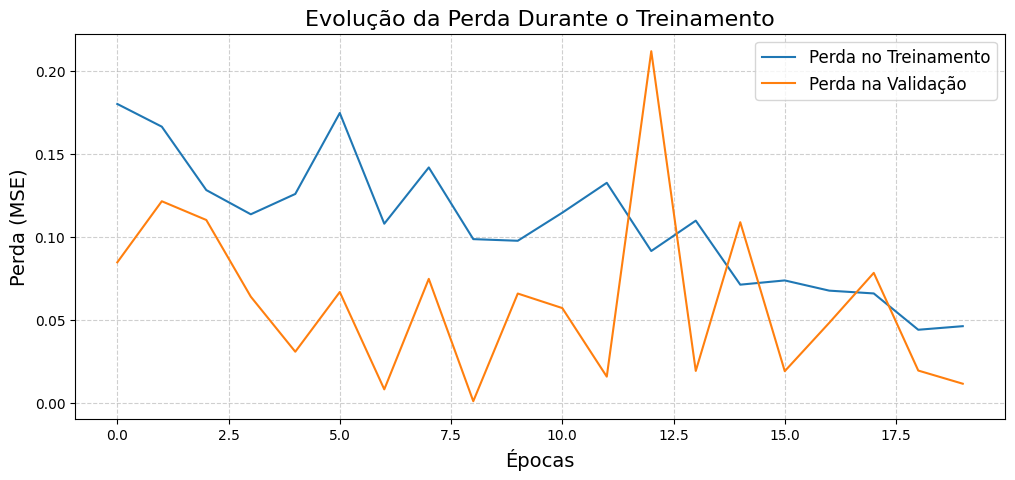

In [ ]:
# @title **Avaliação da perda durante treinamento**
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Perda no Treinamento')
plt.plot(history.history['val_loss'], label='Perda na Validação')

plt.title('Evolução da Perda Durante o Treinamento', fontsize=16)
plt.xlabel('Épocas', fontsize=14)
plt.ylabel('Perda (MSE)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

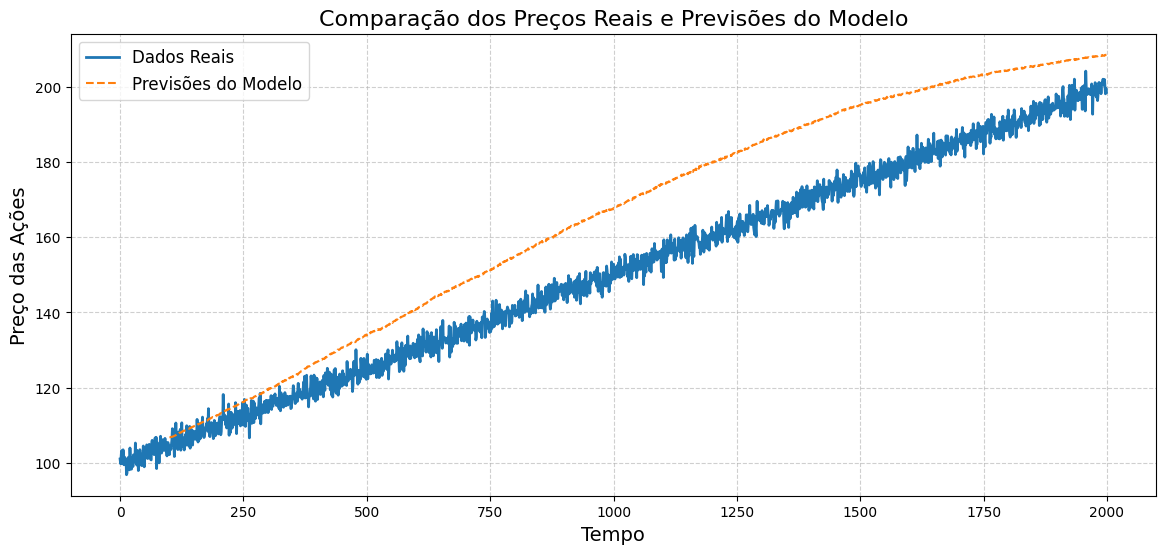

In [ ]:
# @title **Avaliação dos Resultados**
plt.figure(figsize=(14, 6))
plt.plot(scaler.inverse_transform(data), label='Dados Reais', linewidth=2)
plt.plot(np.arange(time_step, time_step + len(predictions)), predictions, label='Previsões do Modelo', linestyle='--')

plt.title('Comparação dos Preços Reais e Previsões do Modelo', fontsize=16)
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Preço das Ações', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Referências**

* Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). **Attention is All You Need**. Advances in Neural Information Processing Systems (NeurIPS 2017), 5998-6008​. Disponível em: https://proceedings.neurips.cc/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf Acesso em: 27 de Mar. de 2025.